In [2]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cns.process.cluster import breaks_to_clusters, merge_clusters
from cns.process.breakpoints import get_breaks_from_cns
from cns.data_utils import main_load_data, save_cns_fig

plt.rcParams.update({'font.size': 12 })


In [4]:
samples, cns = main_load_data()

In [5]:
dict_start = get_breaks_from_cns(cns, False)
# Step 1: Convert the dictionary to a DataFrame
df = pd.DataFrame.from_dict(dict_start, orient='index').transpose()

# Step 2: Calculate the breakpoints per chromosome
breakpoints_per_chr = pd.DataFrame({
    'Chromosome': list(dict_start.keys()),
    'Breakpoints': [len(value) for value in dict_start.values()]
}).set_index('Chromosome')

# Step 3: Calculate the total breakpoints
total_breakpoints = breakpoints_per_chr['Breakpoints'].sum()

# Step 4: Display the DataFrame and the total breakpoints
print("Breakpoints per chromosome:")
print(breakpoints_per_chr)
print("\nTotal breakpoints:", total_breakpoints)

Breakpoints per chromosome:
            Breakpoints
Chromosome             
chr1              65409
chr10             34281
chr11             46645
chr12             48119
chr13             23538
chr14             24558
chr15             19511
chr16             24415
chr17             33678
chr18             22936
chr19             27116
chr2              54456
chr20             23598
chr21             12178
chr22             13218
chr3              54318
chr4              42072
chr5              45526
chr6              50955
chr7              44319
chr8              52686
chr9              33871
chrX              29319
chrY                188

Total breakpoints: 826910


Text(0.5, 1.0, 'Merged breakpoints distribution in chromosome 1, distance 25kb')

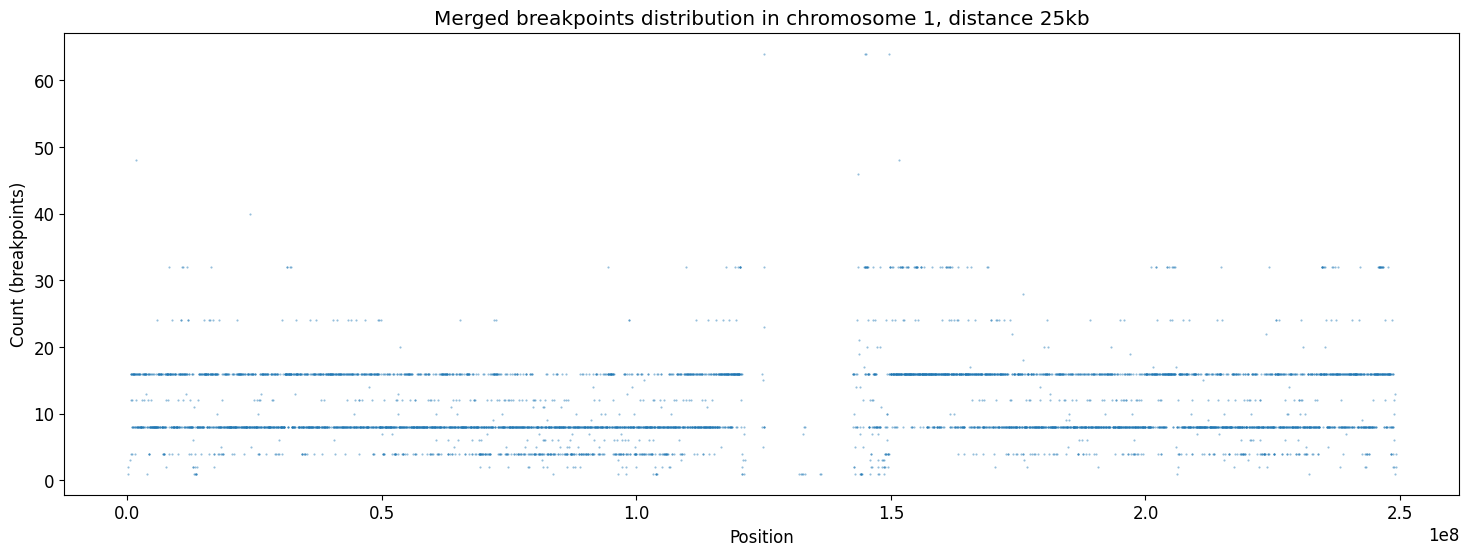

In [6]:
clusters = breaks_to_clusters(dict_start["chr1"])
merged_clusters = merge_clusters(clusters, 25000)

# set image size to 18x3
plt.figure(figsize=(18, 6))
plt.scatter(merged_clusters[:, 0], merged_clusters[:, 1], s=.25, alpha=0.5)
plt.xlabel("Position")
plt.ylabel("Count (breakpoints)")
plt.title("Merged breakpoints distribution in chromosome 1, distance 25kb")

In [7]:
def break_count(breaks):
    return sum(len(values) for values in breaks.values())

In [8]:
import time

from cns.process.cluster import calc_clusters, cluster_within_segments
from cns.utils.conversions import genome_to_segments
chr_clusters = {}
orig_count = break_count(dict_start)
print(f"Reducing {orig_count} breakpoints:")
distances =  [1000 * (2**i) for i in range(11)] 
counts = []
gen_segs = genome_to_segments()
for dist in distances:
    time_start = time.time()
    res = calc_clusters(dict_start, dist)
    counts.append(break_count(res))
    reduction = np.round(counts[-1] / orig_count * 100, 2)
    print(f"Dist: {dist}, count: {counts[-1]}, ratio: {reduction}%, time: {time.time() - time_start:.2f}s")

Reducing 826910 breakpoints:
Dist: 1000, count: 611981, ratio: 74.01%, time: 167.50s
Dist: 2000, count: 478652, ratio: 57.88%, time: 187.09s
Dist: 4000, count: 324737, ratio: 39.27%, time: 119.70s
Dist: 8000, count: 194357, ratio: 23.5%, time: 41.22s
Dist: 16000, count: 108797, ratio: 13.16%, time: 12.03s
Dist: 32000, count: 58477, ratio: 7.07%, time: 5.60s
Dist: 64000, count: 30329, ratio: 3.67%, time: 3.11s
Dist: 128000, count: 15505, ratio: 1.88%, time: 2.04s
Dist: 256000, count: 7841, ratio: 0.95%, time: 1.39s
Dist: 512000, count: 3976, ratio: 0.48%, time: 1.24s
Dist: 1024000, count: 2000, ratio: 0.24%, time: 1.12s


[ 9.96578428 10.96578428 11.96578428 12.96578428 13.96578428 14.96578428
 15.96578428 16.96578428 17.96578428 18.96578428 19.96578428]


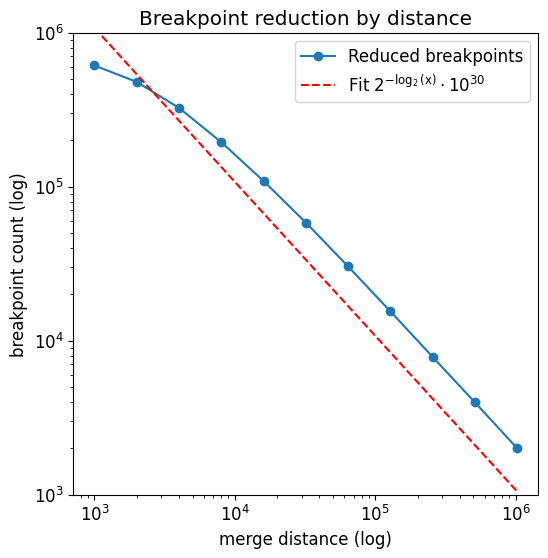

In [9]:
# set plot to 6x6
fig = plt.figure(figsize=(6, 6))
# Step 1: Perform linear regression on the log-transformed data
log_distances = np.log2(distances)
log_counts = np.log2(counts)
slope, intercept = np.polyfit(log_distances, log_counts, 1)
print(log_distances)
# Step 2: Generate the linear fit line
fit_line = 2**(-1 * log_distances + 30.5)
# Step 3: Plot the original data and the fit line
plt.plot(distances, counts, marker='o', label='Reduced breakpoints')
hand_fit = 2**(-log_distances)*2**30
hand_label = r'Fit $2^{-\log_2(\text{x})} \cdot 10^{30}$'
plt.plot(distances, hand_fit, linestyle='--', color='r', label=hand_label)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e3, 1e6)
plt.xlabel('merge distance (log)')
plt.ylabel('breakpoint count (log)')
plt.title('Breakpoint reduction by distance')
plt.legend()
plt.show()
save_cns_fig("breakpoint_reduction", fig)